In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/retail_features.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

In [6]:
customer = df.groupby('CustomerID').agg({
    'InvoiceDate':['max','min'],
    'InvoiceNo':'nunique',
    'Revenue':'sum'
})

In [7]:
customer.columns = [
    'LastPurchase',
    'FirstPurchase',
    'TotalOrders',
    'Revenue'
]

customer.reset_index(inplace=True)

In [8]:
customer['CustomerAge'] = (
    snapshot_date -
    customer['FirstPurchase']
).dt.days

In [9]:
customer['DaysSinceLastPurchase'] = (
    snapshot_date -
    customer['LastPurchase']
).dt.days

Customers who have not made a purchase in the last 90 days are considered churned.

In [10]:
customer['Churn'] = np.where(
    customer['DaysSinceLastPurchase'] > 90,
    1,
    0
)

In [11]:
churn_rate = (
    customer['Churn']
    .mean()
    * 100
)

print(f'Churn Rate: {churn_rate:.2f}%')

Churn Rate: 33.31%


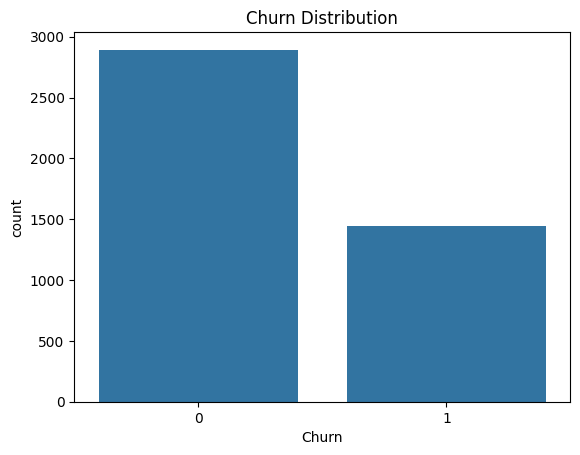

In [32]:
sns.countplot(
    x='Churn',
    data=customer
)

plt.title('Churn Distribution')

plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/churn Distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

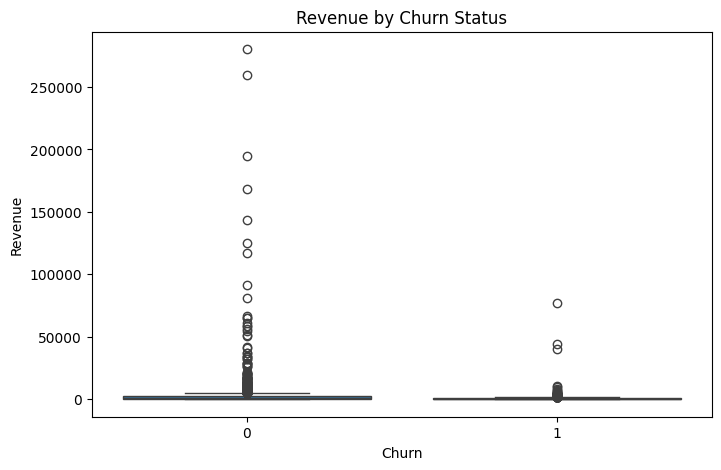

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Revenue',
    data=customer
)

plt.title('Revenue by Churn Status')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/churn Distribution.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

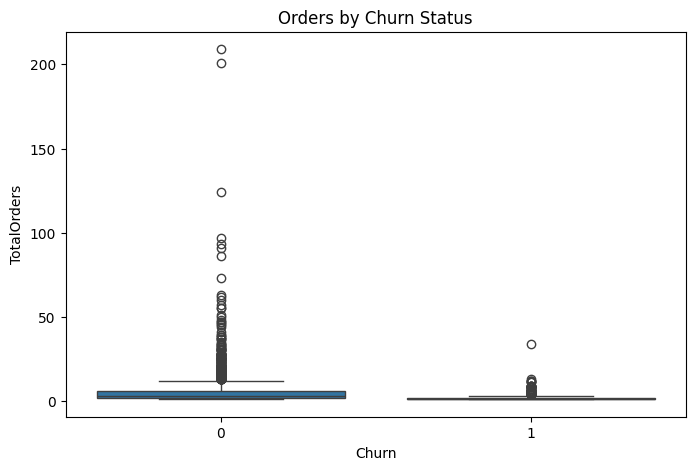

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='TotalOrders',
    data=customer
)

plt.title('Orders by Churn Status')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Orders by Churn Status.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

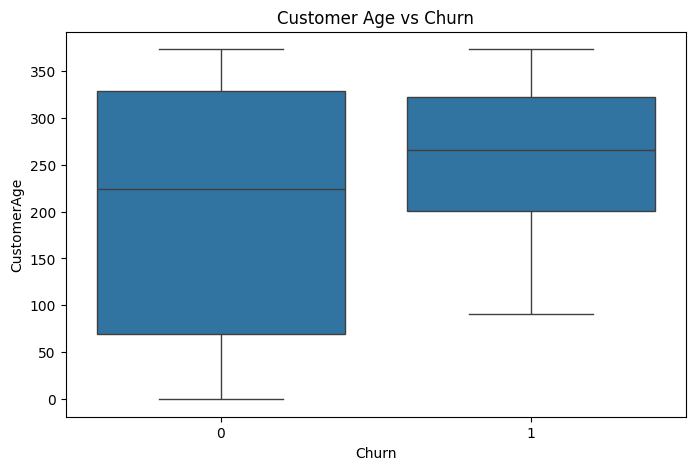

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='CustomerAge',
    data=customer
)

plt.title('Customer Age vs Churn')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Customer Age vs Churn.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [23]:
rfm = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/rfm_customer_segments.csv'
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,At Risk
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,At Risk
3,12349.0,19,1,1757.55,4,1,4,414,Potential Loyalist
4,12350.0,310,1,334.40,1,1,2,112,At Risk


In [24]:
customer = customer.merge(
    rfm[['CustomerID','Segment']],
    on='CustomerID',
    how='left'
)

In [25]:
segment_churn = (
    customer.groupby('Segment')['Churn']
    .mean()
    * 100
).sort_values(ascending=False)

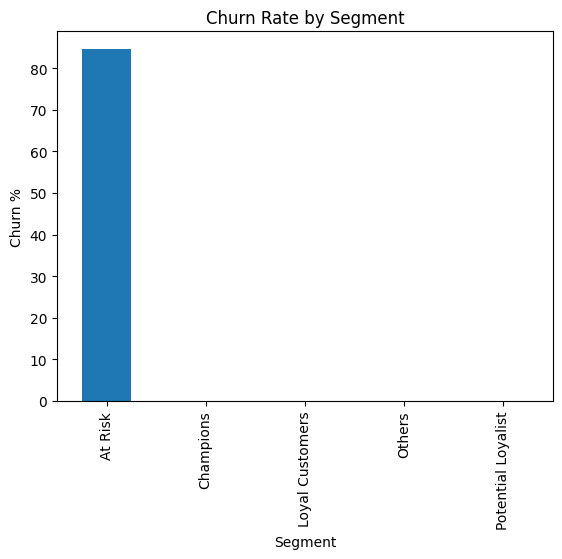

In [36]:
segment_churn.plot(
    kind='bar'
)

plt.title('Churn Rate by Segment')

plt.ylabel('Churn %')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Churn Rate by Segment.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [27]:
corr_cols = [
    'TotalOrders',
    'Revenue',
    'CustomerAge',
    'DaysSinceLastPurchase',
    'Churn'
]

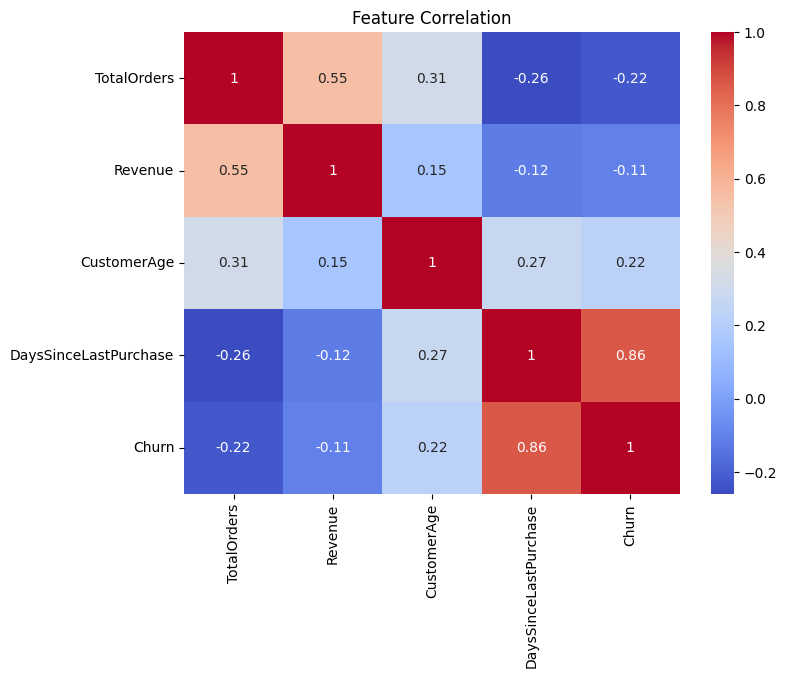

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    customer[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Feature Correlation')
plt.savefig(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/Feature Correlation.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [29]:
customer.groupby('Churn').agg({
    'Revenue':'mean',
    'TotalOrders':'mean',
    'CustomerAge':'mean',
    'DaysSinceLastPurchase':'mean'
})

,Revenue,TotalOrders,CustomerAge,DaysSinceLastPurchase
Churn,,,,
0,2723.139932,5.479087,203.589354,30.894919
1,715.130852,1.855363,259.784775,212.945329


In [30]:
summary = customer.groupby('Churn').agg({
    'Revenue':'mean',
    'TotalOrders':'mean',
    'CustomerAge':'mean',
    'DaysSinceLastPurchase':'mean'
})

summary.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/churn_summary.csv'
)

In [31]:
customer.to_csv(
    '/content/drive/MyDrive/Colab Notebooks/E-Commerce Customer Intelligence & Sales Analytics/data/customer_churn_dataset.csv',
    index=False
)

In [38]:
customer['Churn'].value_counts(normalize=True)

,proportion
Churn,
0,0.666897
1,0.333103
